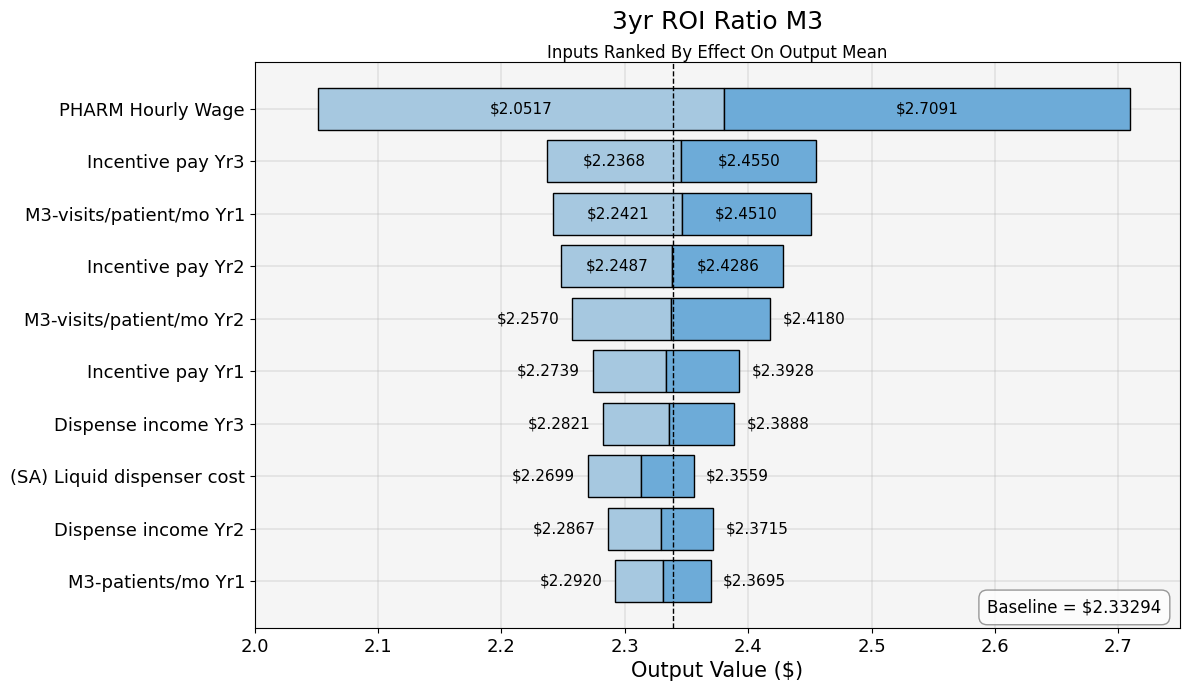

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Load CSV
df = pd.read_csv(r"C:\Users\murra\Downloads\M3_ROI-Ratio_Tornado_2025-07-20(Sheet1).csv")

df.rename(columns={'Unnamed: 0': 'Parameter'}, inplace=True)

df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
df['Y2'] = pd.to_numeric(df['Y2'], errors='coerce')
df['L'] = df['L'].astype(str).str.strip()
df['L2'] = df['L2'].astype(str).str.strip()

df['Mid'] = (df['Y'] + df['Y2']) / 2
df['Diff'] = abs(df['Y2'] - df['Y'])

df = df.sort_values('Diff', ascending=True)

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.facecolor': '#f5f5f5'
})

fig, ax = plt.subplots(figsize=(12, 7))
label_pad = 0.01  # Padding outside bars in data units

def get_text_width_in_data_units(text, fontsize, ax):
    """Estimate width of text in data units on x-axis."""
    renderer = fig.canvas.get_renderer()
    t = ax.text(0, 0, text, fontsize=fontsize)
    bb = t.get_window_extent(renderer=renderer)
    t.remove()
    inv = ax.transData.inverted()
    # Width in pixels
    width_px = bb.width
    # Convert pixels width to data units (x axis)
    x0, _ = inv.transform((0,0))
    x1, _ = inv.transform((width_px, 0))
    return x1 - x0

for _, row in df.iterrows():
    y_pos = row['Parameter']
    y1 = row['Y']
    y2 = row['Y2']

    label_L = f"${float(row['L']):,.4f}"
    label_L2 = f"${float(row['L2']):,.4f}"

    start = min(y1, y2)
    end = max(y1, y2)
    mid = (y1 + y2) / 2

    left_width = mid - start
    right_width = end - mid

    # Draw bars
    ax.barh(y_pos, left_width, left=start, color="#a6c8e0", edgecolor='black')
    ax.barh(y_pos, right_width, left=mid, color="#6dabd8", edgecolor='black')

    # Calculate label widths in data units
    lw_left = get_text_width_in_data_units(label_L, 11, ax)
    lw_right = get_text_width_in_data_units(label_L2, 11, ax)

    # Left label
    if lw_left < left_width - 2*label_pad:
        # Fits inside bar
        x_pos_left = start + left_width / 2
        ha_left = 'center'
    else:
        # Outside bar, just left side with padding
        x_pos_left = start - label_pad
        ha_left = 'right'

    ax.text(x_pos_left, y_pos, label_L, va='center', ha=ha_left, fontsize=11)

    # Right label
    if lw_right < right_width - 2*label_pad:
        x_pos_right = mid + right_width / 2
        ha_right = 'center'
    else:
        x_pos_right = end + label_pad
        ha_right = 'left'

    ax.text(x_pos_right, y_pos, label_L2, va='center', ha=ha_right, fontsize=11)

baseline = df['Mid'].mean()
ax.axvline(x=baseline, color='black', linestyle='--', linewidth=1)

ax.set_xlim(2, 2.75)
ax.set_xlabel('Output Value ($)')
ax.set_title("")
ax.text(0.5, 1.05, "3yr ROI Ratio M3", fontsize=18,
        ha='center', va='bottom', transform=ax.transAxes)
ax.text(0.5, 1.00, "Inputs Ranked By Effect On Output Mean", fontsize=12,
        ha='center', va='bottom', transform=ax.transAxes)
ax.text(
    0.98, 0.02,
    f'Baseline = $2.33294',
    fontsize=12,
    ha='right', va='bottom',
    transform=ax.transAxes,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.8)
)

ax.grid(True, linewidth=0.35, alpha=1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
